In [2]:
import numpy as np
import duckdb

In [3]:
cd "/storage/home/hcoda1/9/pagrawala6/r-js130-0/clone_thesisplots/"

/storage/project/r-js130-0/pagrawala6/clone_thesisplots


In [4]:
# Global variables to store energy data (loaded once)
energies_m = None
J_vals = None


def load_energy_data():
    """Load energy levels from database once"""
    global energies_m, J_vals
    if energies_m is None:
        conn = duckdb.connect('energylevels2.duckdb')
        df = conn.execute(
            "SELECT * FROM energy_levels WHERE el_state = 'X3Sigma-' and J < 150 and v < 40 ORDER BY energy" 
            ).df()
        conn.close()
        
        energies_cm = list(df.energy)
        J_vals = list(df.J)
        energies_m = [(energy_cm + 794.590195753252-791.716307 ) / 1e-2 for energy_cm in energies_cm]
        print(f"Loaded {len(energies_cm)} energy levels")

def Q(T_Kelvin, batch_size=500, tolerance=1e-5, verbose=False):

    """
    Calculate partition function Q for a given temperature
    
    Parameters:
    T_Kelvin: Temperature in Kelvin
    batch_size: Number of energy levels to process per batch
    tolerance: Convergence tolerance
    verbose: Print convergence information
    
    Returns:
    Q: Partition function value
    """
    # Load data if not already loaded
    load_energy_data()
    
    Q_val = 0.0
    Q_old = []
    
    if verbose:
        print(f"Calculating Q for T = {T_Kelvin} K")
    # Constants
    k_b = 1.380649e-23  # Boltzmann constant in J/K
    h = 6.62607015e-34  # Planck constant in J·s
    c = 299792458       # Speed of light in m/s
    cm_to_m = 1e-2      # Convert cm^-1 to m^-1
    # Loop in batches, convert each batch to Joules, accumulate Q
    for i in range(0, len(energies_m), batch_size):
        batch_m = energies_m[i:i + batch_size]
        batch_J = J_vals[i:i + batch_size]
        
        # Convert from cm^-1 to J: E(J) = E(cm^-1) * 100 * h * c
        batch_joules = [(e) * h * c for e in batch_m]
        
        # Calculate partition function contribution for each energy level
        batch_contribution = [(np.exp(-(e)/(k_b * T_Kelvin))) for e in batch_joules]
        batch_degeneracies = [2*J + 1 for J in batch_J]  # Degeneracy factor for each J
        batch_contribution = [contrib * deg for contrib, deg in zip(batch_contribution, batch_degeneracies)]
        
        batch_sum = sum(batch_contribution)
        
        Q_old.append(Q_val)
        Q_val += batch_sum
        
        # Check for convergence
        if abs(Q_val - Q_old[-1]) < tolerance:
            if verbose:
                print(f"Converged after batch {len(Q_old)}")
            break
    
    if verbose:
    
        print(f"Final Q = {Q_val:.6f}")
    
    return Q_val

conn = duckdb.connect('energylevels2.duckdb')

df = conn.execute(
            "SELECT * FROM energy_levels WHERE el_state = 'X3Sigma-'  ORDER BY energy"
            ).df()[['v', 'J', 'lambda', 'sigma', 'omega'
]].drop_duplicates().shape[0]
df



Q(4000, )

Loaded 8957 energy levels


7093.702915670828

In [35]:
case_ids = ['A', 'B', 'C', 'D', 'E']
case_db_paths = {case: f'tests/{case}.duckdb' for case in case_ids}
full_conn_by_case = {case: duckdb.connect(path) for case, path in case_db_paths.items()}
full_conn = full_conn_by_case['A']
# full_conn_by_case[case] now gives the connection for Duo_case

In [14]:
full_conn_by_case['E'].close()

In [36]:
continuum_query = """
SELECT *
FROM duo_oxygen1616_schumannrunge where down_energy < 42025 and down_J < 151 and down_v < 26 and up_energy > 57840 and line_pos < 80000
"""
continuum_by_case = {case: full_conn_by_case[case].execute(continuum_query).df() for case in case_ids}
continuum = continuum_by_case['A'].copy()
# note that continuum IS filtered at this time  - Bound X states only
continuum_by_case['A']

,idx,line_pos,A,Strength,up_el,up_v,up_J,up_lambda,up_sigma,up_omega,up_energy,down_el,down_v,down_J,down_lambda,down_sigma,down_omega,down_energy,Intensity
0,49,79082.0670,7.703083e+02,1.489874e-05,B3Sigma-,321,1.0,0.0,-1.0,-1.0,79084.9322,X3Sigma-,0,0.0,0.0,0.0,0.0,2.8652,6.946394e-23
1,51,79894.3455,5.754769e+00,1.079441e-07,B3Sigma-,327,1.0,0.0,-1.0,-1.0,79897.2107,X3Sigma-,0,0.0,0.0,0.0,0.0,2.8652,5.084482e-25
2,52,65771.6584,3.424207e+05,1.151231e-02,B3Sigma-,201,1.0,0.0,-1.0,-1.0,65774.5236,X3Sigma-,0,0.0,0.0,0.0,0.0,2.8652,4.464094e-20
3,55,64759.7017,2.309974e+05,8.136013e-03,B3Sigma-,189,1.0,0.0,-1.0,-1.0,64762.5669,X3Sigma-,0,0.0,0.0,0.0,0.0,2.8652,3.106335e-20
4,58,65258.1424,2.835078e+05,9.758430e-03,B3Sigma-,195,1.0,0.0,-1.0,-1.0,65261.0076,X3Sigma-,0,0.0,0.0,0.0,0.0,2.8652,3.754451e-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8679628,14042348,59051.9395,1.666675e+01,7.768063e-05,B3Sigma-,428,150.0,0.0,-1.0,-1.0,100514.7275,X3Sigma-,11,150.0,0.0,1.0,1.0,41462.7881,9.025901e-29
8679629,14042349,61263.7606,1.536213e+01,6.412165e-05,B3Sigma-,440,150.0,0.0,-1.0,-1.0,102726.5486,X3Sigma-,11,150.0,0.0,1.0,1.0,41462.7881,7.729510e-29
8679630,14042350,21800.8860,1.251686e-19,1.159410e-23,B3Sigma-,117,150.0,0.0,-1.0,-1.0,63263.6741,X3Sigma-,11,150.0,0.0,1.0,1.0,41462.7881,4.971463e-48
8679631,14042351,48799.1552,9.472220e+00,7.823105e-05,B3Sigma-,368,150.0,0.0,-1.0,-1.0,90261.9433,X3Sigma-,11,150.0,0.0,1.0,1.0,41462.7881,7.511645e-29


In [37]:
continuum.sort_values(by='up_energy')



,idx,line_pos,A,Strength,up_el,up_v,up_J,up_lambda,up_sigma,up_omega,up_energy,down_el,down_v,down_J,down_lambda,down_sigma,down_omega,down_energy,Intensity
4560696,7386267,30446.9137,3.116070e+05,5.808434e+00,B3Sigma-,18,82.0,0.0,-1.0,-1.0,57840.6902,X3Sigma-,14,81.0,0.0,1.0,1.0,27393.7766,5.486609e-22
4493890,7288721,46014.3991,1.000729e-23,5.338518e-29,B3Sigma-,18,81.0,0.0,0.0,0.0,57840.6902,X3Sigma-,2,80.0,0.0,1.0,1.0,11826.2912,2.060017e-48
4499406,7297249,41469.5743,8.171693e+05,5.955369e+00,B3Sigma-,18,81.0,0.0,0.0,0.0,57840.6902,X3Sigma-,5,80.0,0.0,0.0,0.0,16371.1159,4.038618e-20
4559337,7384323,33902.9719,5.803430e+05,7.835256e+00,B3Sigma-,18,82.0,0.0,-1.0,-1.0,57840.6902,X3Sigma-,11,81.0,0.0,1.0,1.0,23937.7183,2.856801e-21
4626453,7482855,42361.2203,2.000746e-03,1.401525e-08,B3Sigma-,18,83.0,0.0,-1.0,-1.0,57840.6902,X3Sigma-,4,82.0,0.0,0.0,0.0,15479.4699,1.337983e-28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7935207,12582660,79886.5304,1.218393e+05,2.049825e-01,B3Sigma-,539,134.0,0.0,-1.0,-1.0,121879.0296,X3Sigma-,15,135.0,0.0,1.0,1.0,41992.4992,2.663092e-25
7927426,12557832,79886.5304,9.103432e-05,1.542949e-10,B3Sigma-,535,135.0,0.0,-1.0,-1.0,121879.0296,X3Sigma-,15,134.0,0.0,0.0,0.0,41992.4992,2.004568e-34
7951375,12607876,79886.5304,6.636311e+00,1.124794e-05,B3Sigma-,535,135.0,0.0,-1.0,-1.0,121879.0296,X3Sigma-,15,135.0,0.0,1.0,1.0,41992.4992,1.461310e-29
8035740,12753475,79930.2712,5.850968e-20,1.004672e-25,B3Sigma-,539,137.0,0.0,0.0,0.0,121922.7704,X3Sigma-,15,136.0,0.0,1.0,1.0,41992.4992,1.305965e-49


In [38]:
# Build case-wise continuum tables and smoothing widths
import pandas as pd
import matplotlib.pyplot as plt

def add_smoothing_widths(df):
    valid_subset = df[(df['up_v'] != -1) & (df['up_J'] == 108)].copy()
    vib_levels = valid_subset.groupby('up_v')['up_energy'].min().reset_index()
    vib_levels = vib_levels.sort_values('up_v')

    v_list = vib_levels['up_v'].tolist()
    e_list = vib_levels['up_energy'].tolist()

    smoothing_widths = []
    count = len(e_list)

    for i in range(count):
        if i < count - 1:
            diff = e_list[i + 1] - e_list[i]
            smoothing_widths.append(diff)
        else:
            if len(smoothing_widths) > 0:
                smoothing_widths.append(smoothing_widths[-1])
            else:
                smoothing_widths.append(0.0)

    width_map = dict(zip(v_list, smoothing_widths))

    processed = df.sort_values(by='up_energy').copy()
    processed['smoothing_widths'] = processed['up_v'].map(width_map)
    processed['smoothing_widths'] = processed['smoothing_widths'].ffill().bfill()

    window_size = min(20, len(smoothing_widths)) if len(smoothing_widths) else 1
    rolling_widths = np.convolve(smoothing_widths, np.ones(window_size) / window_size, mode='same') if len(smoothing_widths) else np.array([])

    grouped = processed.groupby(
        ['down_v', 'down_J', 'down_lambda', 'down_sigma', 'down_omega', 'down_energy']
    ).agg({
        'A': list,
        'line_pos': list,
        'up_energy': list,
        'up_J': list,
        'up_v': list,
        'smoothing_widths': list
    }).reset_index()

    return {
        'continuum': processed,
        'width_map': width_map,
        'v_list': v_list,
        'e_list': e_list,
        'smoothing_widths': smoothing_widths,
        'rolling_widths': rolling_widths,
        'continuum_grouped': grouped,
    }

case_data = {case: add_smoothing_widths(df) for case, df in continuum_by_case.items()}
continuum = case_data['A']['continuum']
width_map = case_data['A']['width_map']
vib_levels = pd.DataFrame({'up_v': case_data['A']['v_list'], 'up_energy': case_data['A']['e_list']})
v_list = case_data['A']['v_list']
e_list = case_data['A']['e_list']
smoothing_widths = case_data['A']['smoothing_widths']
rolling_widths = case_data['A']['rolling_widths']
continuum_grouped = case_data['A']['continuum_grouped']
malformed_sample = continuum[continuum['up_v'] == -1].head()

if not malformed_sample.empty:
    print("Processing Complete. Sample of corrected 'up_v = -1' rows:")
    print(malformed_sample[['up_v', 'up_energy', 'smoothing_widths']])
else:
    print("Processing Complete. No 'up_v = -1' rows found in snippet.")

Processing Complete. No 'up_v = -1' rows found in snippet.


Duo_A - Max up_v: 545
Duo_A - Min up_v: 4
Duo_A - Number of levels found: 542
------------------------------
Dictionary of {v: Energy}:
[(4, 57846.8652), (5, 57870.3451), (6, 57893.5976), (7, 57916.7447), (8, 57939.8682), (9, 57963.0254), (10, 57986.2577), (11, 58009.5954), (12, 58033.0611), (13, 58040.7937)]
Duo_B - Max up_v: 544
Duo_B - Min up_v: 13
Duo_B - Number of levels found: 532
------------------------------
Dictionary of {v: Energy}:
[(13, 57854.4605), (14, 57879.0218), (15, 57903.8143), (16, 57928.849), (17, 57954.1349), (18, 57979.6798), (19, 58005.49), (20, 58031.5706), (21, 58057.9263), (22, 58084.5608)]
Duo_C - Max up_v: 545
Duo_C - Min up_v: 16
Duo_C - Number of levels found: 530
------------------------------
Dictionary of {v: Energy}:
[(16, 57840.7596), (17, 57866.0456), (18, 57891.5904), (19, 57917.4006), (20, 57943.4813), (21, 57969.8369), (22, 57996.4714), (23, 58023.3878), (24, 58050.5886), (25, 58078.0761)]
Duo_D - Max up_v: 783
Duo_D - Min up_v: 35
Duo_D - Numbe

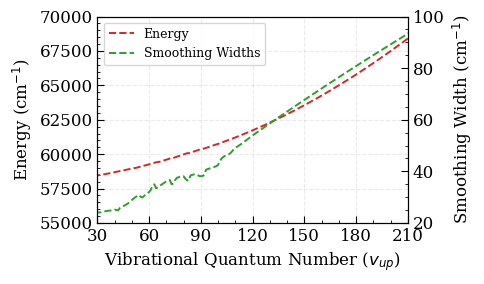

In [21]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# ──────────────────────────────────────────────
# Data extraction (unchanged physics)
# ──────────────────────────────────────────────
case_labels = {case: f'Duo_{case}' for case in case_ids}

for case in case_ids:
    v_list_case = case_data[case]['v_list']
    e_list_case = case_data[case]['e_list']
    energy_dict = dict(zip(v_list_case, e_list_case))
    print(f"{case_labels[case]} - Max up_v: {max(v_list_case)}")
    print(f"{case_labels[case]} - Min up_v: {min(v_list_case)}")
    print(f"{case_labels[case]} - Number of levels found: {len(v_list_case)}")
    print("-" * 30)
    print("Dictionary of {v: Energy}:")
    print(list(energy_dict.items())[:10])

# reuse Duo_A for the single-case plot below so the existing figure stays valid
v_list = case_data['A']['v_list']
e_list = case_data['A']['e_list']
smoothing_widths = case_data['A']['smoothing_widths']
rolling_widths = case_data['A']['rolling_widths']

# print("v\tEnergy\tSmoothing Width")
# for v, e, sw in zip(v_list, e_list, smoothing_widths):
#     print(f"{v}\t{e:.2f}\t{sw:.2f}")

# width_map = dict(zip(v_list, smoothing_widths))
# print(width_map)

# ──────────────────────────────────────────────
# Plot (merged, twin axis, styled)
# ──────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
})

FIGSIZE = (5, 3)

LW = 1.4
MS = 4

fig, ax1 = plt.subplots(figsize=FIGSIZE)

# --- Left axis: Energy ---
ax1.plot(
    v_list, e_list,
    linestyle='--',
    linewidth=LW,
    color='tab:red',
    label='Energy'
)
ax1.set_xlabel(r'Vibrational Quantum Number ($v_{up}$)')
ax1.set_ylabel(r'Energy (cm$^{-1}$)', color='black')

# --- Right axis: Smoothing widths ---
ax2 = ax1.twinx()
# ax2.plot(
#     v_list, smoothing_widths,
#     linestyle='--',
#     linewidth=LW,
#     color='tab:blue',
#     label='Smoothing Width'
# ) 
# plot rolling average of widths for better visualization
window_size = 20
rolling_widths = np.convolve(smoothing_widths, np.ones(window_size)/window_size
, mode='same')
ax2.plot(
    v_list, rolling_widths,
    linestyle='--',
    linewidth=LW,
    color='tab:green',
    label='Smoothing Widths'
)


ax2.set_ylabel(r'Smoothing Width (cm$^{-1}$)', color='black')

from matplotlib.ticker import AutoMinorLocator, MultipleLocator

# ax1 owns: bottom and left only
ax1.tick_params(which='major', direction='in', length=5,
                top=False, bottom=True, left=True, right=False)
ax1.tick_params(which='minor', direction='in', length=2.5,
                top=False, bottom=True, left=True, right=False)

ax1.xaxis.set_major_locator(MultipleLocator(30))   # major every 20

ax1.xaxis.set_minor_locator(MultipleLocator(10))    # minor every 5 — all integers

ax1.yaxis.set_minor_locator(AutoMinorLocator())    # energy is continuous, fine here

# ax2 owns: top and right
ax2.tick_params(which='major', direction='in', length=5,
                top=True, bottom=False, left=False, right=True)
ax2.tick_params(which='minor', direction='in', length=2.5,
                top=True, bottom=False, left=False, right=True)
ax2.yaxis.set_minor_locator(AutoMinorLocator())

ax1.grid(True, ls='--', alpha=0.25)
ax1.set_xlim(30, 210)
ax1.set_ylim(55000, 70000)

ax2.set_ylim(20, 100)
# --- Combined legend ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, frameon=True, fontsize=9)
plt.savefig("cont_1.svg", format="svg", bbox_inches='tight')
plt.tight_layout()
plt.show()

In [22]:
# insert smoothing widths back into continuum dataframe
continuum['smoothing_widths'] = continuum['up_v'].map(width_map)
continuum[continuum['up_v'] == 1]

,idx,line_pos,A,Strength,up_el,up_v,up_J,up_lambda,up_sigma,up_omega,up_energy,down_el,down_v,down_J,down_lambda,down_sigma,down_omega,down_energy,Intensity,smoothing_widths
7202686,11326566,36331.8787,1.000782e-24,1.643504e-29,B3Sigma-,1,123.0,0.0,0.0,0.0,57849.5019,X3Sigma-,1,122.0,0.0,1.0,1.0,21517.6232,1.533557e-50,NaN
7315163,11506657,24529.2987,1.300395e-22,6.995473e-27,B3Sigma-,1,124.0,0.0,-1.0,-1.0,57849.5019,X3Sigma-,10,124.0,0.0,0.0,0.0,33320.2031,6.314825e-50,NaN
7404858,11655055,26723.0918,8.186779e-17,3.433400e-21,B3Sigma-,1,125.0,0.0,-1.0,-1.0,57849.5019,X3Sigma-,8,126.0,0.0,1.0,1.0,31126.4100,7.433694e-44,NaN
7326970,11527743,33767.0127,8.835681e-24,1.836681e-28,B3Sigma-,1,125.0,0.0,-1.0,-1.0,57849.5019,X3Sigma-,2,124.0,0.0,0.0,0.0,24082.4892,6.331405e-50,NaN
7398146,11645887,30724.0558,2.597952e-25,7.169138e-30,B3Sigma-,1,125.0,0.0,-1.0,-1.0,57849.5019,X3Sigma-,4,126.0,0.0,0.0,0.0,27125.4461,7.526007e-52,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8643223,13966522,18526.5530,9.914295e-17,1.496381e-20,B3Sigma-,1,150.0,0.0,-1.0,-1.0,57995.0662,X3Sigma-,9,149.0,0.0,1.0,1.0,39468.5132,1.116241e-44,NaN
8619661,13899873,16127.3144,5.952102e-27,1.352861e-30,B3Sigma-,1,149.0,0.0,0.0,0.0,57995.0662,X3Sigma-,12,148.0,0.0,1.0,1.0,41867.7519,3.699836e-55,NaN
8665164,14001822,17524.7156,5.972308e-26,1.057933e-29,B3Sigma-,1,149.0,0.0,0.0,0.0,57995.0662,X3Sigma-,10,150.0,0.0,1.0,1.0,40470.3507,5.203425e-54,NaN
8654810,13988158,22620.6294,2.055054e-26,1.692693e-30,B3Sigma-,1,149.0,0.0,0.0,0.0,57995.0662,X3Sigma-,5,150.0,0.0,1.0,1.0,35374.4368,6.729463e-54,NaN


In [23]:
continuum[continuum['up_v'] == 140]

,idx,line_pos,A,Strength,up_el,up_v,up_J,up_lambda,up_sigma,up_omega,up_energy,down_el,down_v,down_J,down_lambda,down_sigma,down_omega,down_energy,Intensity,smoothing_widths
26695,46153,39258.2728,2.769648e+04,4.378749e-03,B3Sigma-,140,1.0,0.0,-1.0,-1.0,61267.2060,X3Sigma-,16,1.0,0.0,1.0,1.0,22008.9332,3.699764e-24,63.4328
17941,31343,55088.4710,5.104229e+04,2.920566e-03,B3Sigma-,140,1.0,0.0,-1.0,-1.0,61267.2060,X3Sigma-,4,1.0,0.0,1.0,1.0,6178.7350,1.028743e-21,63.4328
61905,106693,38074.0169,2.505425e+04,4.342245e-03,B3Sigma-,140,1.0,0.0,-1.0,-1.0,61267.2060,X3Sigma-,17,2.0,0.0,1.0,1.0,23193.1891,2.324016e-24,63.4328
39301,67660,59697.2104,5.943272e+05,2.672284e-02,B3Sigma-,140,1.0,0.0,-1.0,-1.0,61267.2060,X3Sigma-,1,2.0,0.0,1.0,1.0,1569.9955,5.352565e-20,63.4328
2239,4409,56610.0992,3.018005e+04,1.591319e-03,B3Sigma-,140,1.0,0.0,-1.0,-1.0,61267.2060,X3Sigma-,3,0.0,0.0,0.0,0.0,4657.1068,9.957008e-22,63.4328
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8678973,14041512,23627.1344,6.443099e-02,4.688414e-06,B3Sigma-,140,150.0,0.0,-1.0,-1.0,64735.1234,X3Sigma-,10,150.0,0.0,0.0,0.0,41107.9890,2.475805e-30,63.4328
8671225,14031271,31532.5712,6.903623e-07,2.113310e-11,B3Sigma-,140,150.0,0.0,-1.0,-1.0,64735.1234,X3Sigma-,3,150.0,0.0,1.0,1.0,33202.5521,2.558699e-34,63.4328
8678469,14040855,24264.7727,5.861618e-02,3.937795e-06,B3Sigma-,140,150.0,0.0,-1.0,-1.0,64735.1234,X3Sigma-,10,150.0,0.0,1.0,1.0,40470.3507,2.686176e-30,63.4328
8641434,13964171,29360.6865,1.459396e+00,5.533997e-05,B3Sigma-,140,150.0,0.0,-1.0,-1.0,64735.1234,X3Sigma-,5,149.0,0.0,1.0,1.0,35374.4368,2.856396e-28,63.4328


In [24]:
continuum_grouped = continuum.groupby(
    ['down_v', 'down_J', 'down_lambda', 'down_sigma', 'down_omega', 'down_energy']
).agg({
    'A': list,
    'line_pos': list,
    'up_energy': list,      # optional, if you want to retain upper state quantum numbers
    'up_J': list,
    'up_v': list,
    'smoothing_widths': list
    # add more columns as needed
}).reset_index()

continuum_grouped

,down_v,down_J,down_lambda,down_sigma,down_omega,down_energy,A,line_pos,up_energy,up_J,up_v,smoothing_widths
0,0,0.0,0.0,0.0,0.0,2.8652,"[1084.2951, 2158.78564, 1129.10233, 2248.12583...","[57843.9328, 57844.4644, 57865.7091, 57866.246...","[57846.798, 57847.3295, 57868.5742, 57869.1111...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[58, 58, 59, 59, 60, 60, 61, 61, 62, 62, 63, 6...","[35.08439999999973, 35.08439999999973, 35.5468..."
1,0,1.0,0.0,1.0,1.0,2.8652,"[3252.88529, 2914.36061, 1619.08923, 3387.3069...","[57843.9328, 57844.4644, 57844.4644, 57865.709...","[57846.798, 57847.3295, 57847.3295, 57868.5742...","[1.0, 2.0, 1.0, 1.0, 2.0, 1.0, 1.0, 1.0, 2.0, ...","[58, 58, 58, 59, 59, 59, 60, 60, 60, 61, 61, 6...","[35.08439999999973, 35.08439999999973, 35.0843..."
2,0,2.0,0.0,0.0,0.0,17.1904,"[1.4304455e-17, 649.01686, 5841.15174, 13.2452...","[57829.6076, 57830.1391, 57830.1391, 57830.139...","[57846.798, 57847.3295, 57847.3295, 57847.3295...","[1.0, 2.0, 1.0, 3.0, 3.0, 1.0, 3.0, 1.0, 2.0, ...","[58, 58, 58, 58, 58, 59, 59, 59, 59, 59, 60, 6...","[35.08439999999973, 35.08439999999973, 35.0843..."
3,0,2.0,0.0,1.0,1.0,2.8652,"[5421.47549, 971.453538, 3885.81415, 107.93928...","[57843.9328, 57844.4644, 57844.4644, 57844.464...","[57846.798, 57847.3295, 57847.3295, 57847.3295...","[1.0, 2.0, 3.0, 1.0, 3.0, 1.0, 1.0, 3.0, 2.0, ...","[58, 58, 58, 58, 58, 59, 59, 59, 59, 59, 60, 6...","[35.08439999999973, 35.08439999999973, 35.0843..."
4,0,3.0,0.0,1.0,1.0,17.1904,"[5192.13488, 463.583471, 344.019558, 4013.5615...","[57830.1391, 57830.1391, 57831.3801, 57831.380...","[57847.3295, 57847.3295, 57848.5705, 57848.570...","[2.0, 3.0, 3.0, 4.0, 2.0, 3.0, 3.0, 4.0, 2.0, ...","[58, 58, 58, 58, 59, 59, 59, 59, 60, 60, 60, 6...","[35.08439999999973, 35.08439999999973, 35.0843..."
...,...,...,...,...,...,...,...,...,...,...,...,...
4419,20,94.0,0.0,0.0,0.0,41698.6477,"[7.91191777e-26, 1.20388736e-17, 50.2028384, 1...","[16145.8958, 16148.3717, 16152.3, 16157.2752, ...","[57844.5435, 57847.0194, 57850.9477, 57855.922...","[93.0, 95.0, 95.0, 94.0, 93.0, 95.0, 93.0, 95....","[13, 10, 11, 12, 12, 12, 13, 12, 14, 13, 13, 1...","[15.8778999999995, 23.337699999996403, 23.4657..."
4420,20,94.0,0.0,1.0,1.0,40992.8709,"[1.32187084e-17, 1.32899027e-24, 4.12779603e-2...","[16851.6727, 16854.1486, 16858.0768, 16863.052...","[57844.5435, 57847.0194, 57850.9477, 57855.922...","[93.0, 95.0, 95.0, 95.0, 93.0, 94.0, 93.0, 95....","[13, 10, 11, 12, 12, 12, 13, 12, 14, 13, 13, 1...","[15.8778999999995, 23.337699999996403, 23.4657..."
4421,20,95.0,0.0,1.0,1.0,41698.6477,"[1.2012497e-17, 1.31931283e-21, 50.2028956, 0....","[16148.3717, 16148.3717, 16152.3, 16152.3, 161...","[57847.0194, 57847.0194, 57850.9477, 57850.947...","[96.0, 95.0, 96.0, 95.0, 94.0, 95.0, 95.0, 96....","[10, 10, 11, 11, 12, 12, 12, 12, 13, 13, 13, 1...","[23.337699999996403, 23.337699999996403, 23.46..."
4422,20,96.0,0.0,1.0,1.0,41698.6477,"[1.57092658e-24, 1.20355564e-17, 1.30358261e-2...","[16148.3717, 16148.3717, 16148.3717, 16152.3, ...","[57847.0194, 57847.0194, 57847.0194, 57850.947...","[95.0, 97.0, 96.0, 97.0, 95.0, 96.0, 95.0, 97....","[10, 9, 10, 10, 11, 11, 12, 11, 11, 12, 12, 13...","[23.337699999996403, 23.232300000003306, 23.33..."


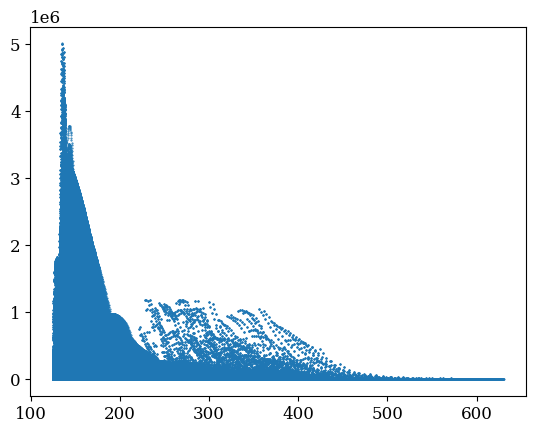

In [25]:
plt.plot(1e7/continuum['line_pos'], continuum['A'], '.', markersize=1)

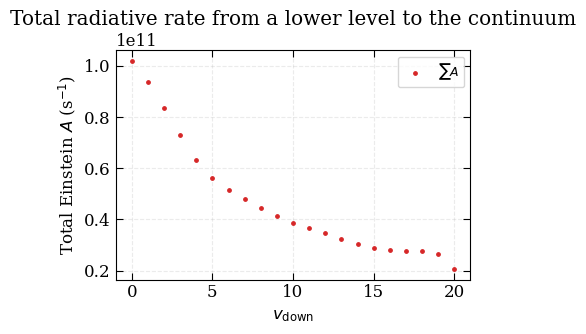

In [26]:
from matplotlib.ticker import MultipleLocator
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, LogLocator, NullFormatter
import numpy as np

stats = continuum.groupby('down_v')['A'].agg(
    A_sum='sum',
    A_max='max',
    A_p90=lambda x: x.quantile(0.90)
).reset_index().sort_values('down_v')

fig, ax = plt.subplots(figsize=(4.5, 3.5))

# --- swapped axes ---
ax.scatter(stats['down_v'], stats['A_sum'],
           s=6, color='tab:red', label=r'$\sum A$', zorder=3)
# ax.scatter(stats['down_v'], stats['A_max'],
#            s=6, color='tab:blue', marker='s', label=r'$A_\mathrm{max}$', zorder=3)
# # ax.scatter(stats['down_v'], stats['A_p90'],
#            s=6, color='tab:green', marker='^', label=r'90th percentile', zorder=3)

# log now on Y (since A moved to Y)
# ax.set_yscale('log')
# ax.invert_yaxis()

ax.set_xlabel(r'$v_\mathrm{down}$')
ax.set_ylabel(r'Total Einstein $A$ (s$^{-1}$)')

ax.tick_params(which='major', direction='in', length=5,
               top=True, bottom=True, left=True, right=True)
ax.tick_params(which='minor', direction='in', length=2.5,
               top=True, bottom=True, left=True, right=True)

# ax.set_ylim(1e9, 1e12)

# replace the yaxis minor locator line with:
# ax.yaxis.set_major_locator(LogLocator(base=10, numticks=2))
# ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10), numticks=15))
# ax.yaxis.set_minor_formatter(NullFormatter())  # ticks but no labels

ax.legend(fontsize=9, frameon=True)
ax.grid(True, ls='--', alpha=0.25)
plt.title("Total radiative rate from a lower level to the continuum")
plt.tight_layout()
plt.savefig("cont_2.svg", format="svg", bbox_inches='tight')
plt.show()

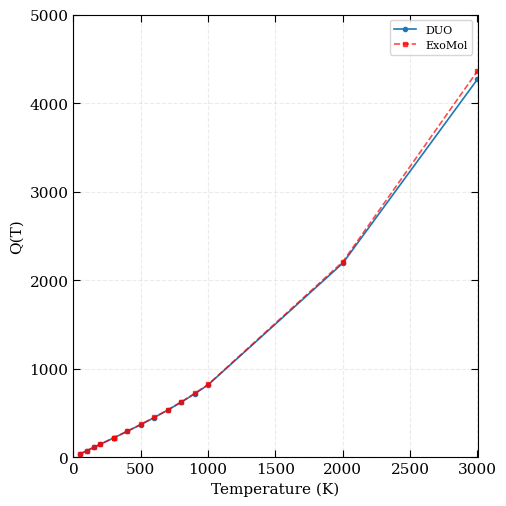

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# 1. Full data from table (ExoMol/ESA)
exomol_T = np.array([
    50, 100, 150, 200, 298.15, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 
    3000, 4000, 5000, 6000, 7000, 8000, 9000
], dtype=float)

exomol_Q = np.array([
    36.97, 73.45, 109.9, 146.4, 218.2, 219.6, 293.7, 369.9, 449.8, 534.2, 623.9, 
    719.4, 820.9, 2207.0, 4362.0, 7452.0, 11660.0, 17190.0, 24250.0, 33020.0, 
    43650.0
], dtype=float)

# 2. Local styling and comparison
plt.rcParams.update({"font.family": "serif", "font.size": 11})
FIGSIZE = (5.2, 5.2)
LW, MS = 1.2, 3 # this is for line width and marker size in the plot

# Dummy DUO data for example (subset of ExoMol for comparison)
temperatures = exomol_T
q_vals = np.array([Q(float(T)) for T in temperatures])

fig, ax = plt.subplots(figsize=FIGSIZE)

# Plot DUO
ax.plot(temperatures, q_vals, '-o', lw=LW, ms=MS, label='DUO')

# Plot ExoMol
ax.plot(exomol_T, exomol_Q, '--s', lw=LW, ms=MS, label='ExoMol', alpha=0.7, color='red')

ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Q(T)")
ax.set_xlim(0,3000)
ax.set_ylim(0, 5000)
# ax.set_yscale('log')
# ax.set_xscale('log')

ax.tick_params(which='major', direction='in', length=5, top=True, right=True)
ax.grid(True, ls="--", alpha=0.25)
ax.legend(frameon=True, fontsize=8)
plt.savefig('disc_Qcomparison.svg', format = 'svg', bbox_inches='tight')
plt.tight_layout()
plt.show()

In [39]:
case_qt = {}
T = 300  # Temperature in Kelvin
down_J_by_case = {}
down_energy_by_case = {}
k_b = 1.380649e-23
h = 6.62607015e-34
c = 299792458
for case in case_ids:
    grouped = case_data[case]['continuum_grouped']
    down_J_by_case[case] = grouped['down_J'].tolist()
    down_energy_by_case[case] = grouped['down_energy'].tolist()
    energies_wn = [energy_cm / 1e-2 for energy_cm in down_energy_by_case[case]]
    batch_joules = [energy_wn * h * c for energy_wn in energies_wn]
    degeneracies = [2 * J + 1 for J in down_J_by_case[case]]
    case_qt[case] = sum(np.exp(-(e) / (k_b * T)) * deg for e, deg in zip(batch_joules, degeneracies))

Q_T_by_case = case_qt
Q_T = Q_T_by_case['A']
down_J_list = down_J_by_case['A']
down_energy_list = down_energy_by_case['A']

## Variable wavelength compute engine

In [40]:
# Parallel computation of the cross-section
import numpy as np
from concurrent.futures import ThreadPoolExecutor
import threading
from typing import Tuple, List
import time
c = 2.99792458e10  # speed of light in cm/s
h = 6.62607015e-34  # Planck's constant in J*s
k_B = 1.380649e-23  # Boltzmann's constant in J/K


Q_T = Q_T_by_case['A']  # Default partition function at temperature T


def gaussian_lineprofile(nu, nu_nominal, alpha_D):
    """Compute Gaussian line profile"""
    return np.sqrt(np.log(2)/np.pi) * (1/alpha_D) * np.exp(-np.log(2) * (nu - nu_nominal)**2 / alpha_D**2)

def process_transition_chunk_vectorized(args):
    """
    Process a chunk of transitions using vectorized operations with frequency masking.
    Adapted for variable alpha_D (Doppler width) per transition.
    
    Args:
        args: tuple containing (line_positions, intensities, nu_range, alpha_D_array, thread_id)
    
    Returns:
        numpy array with accumulated cross-section contributions
    """
    line_positions, intensities, nu_range, alpha_D, thread_id = args
    
    # 1. Reshape inputs for broadcasting
    # nu_grid shape: (1, n_freq)
    nu_grid = nu_range[np.newaxis, :]
    
    # pos_grid shape: (n_trans, 1)
    pos_grid = line_positions[:, np.newaxis]
    
    # alpha_D shape: (n_trans, 1) <--- CRITICAL CHANGE
    # Ensure alpha_D is a column vector so it corresponds to each transition row
    alpha_D_col = alpha_D[:, np.newaxis]
    
    # 2. Variable Cutoff
    # Now cutoff_range is an array of shape (n_trans, 1), not a scalar
    cutoff_range = 3 * alpha_D_col
    
    # 3. Create Distance Matrix
    # Shape: (n_trans, n_freq)
    distances = nu_grid - pos_grid
    
    # 4. Apply frequency masking
    # This now compares the distance matrix against the per-row cutoff_range
    mask = np.abs(distances) <= cutoff_range
    
    # 5. Initialize Gaussian container
    gaussians = np.zeros_like(distances)
    
    # 6. Compute Gaussians only on masked values
    # We must extract the specific alpha_D values that match the valid points in the mask.
    # np.broadcast_to creates a view (cheap) that repeats alpha_D_col across columns.
    # Then [mask] flattens it to match the selected 'distances[mask]'.
    alpha_active = np.broadcast_to(alpha_D_col, mask.shape)[mask]
    dist_active = distances[mask]
    
    # Pre-calculate constants to save operations inside the exponent
    sqrt_ln2_pi = np.sqrt(np.log(2) / np.pi)
    ln2 = np.log(2)
    
    # Vectorized Gaussian formula
    gaussians[mask] = (sqrt_ln2_pi * (1 / alpha_active) * np.exp(-ln2 * (dist_active**2) / (alpha_active**2)))
    
    # 7. Weight by intensities and sum
    # intensities shape: (n_trans, 1)
    weighted = gaussians * intensities[:, np.newaxis]
    
    # Sum down the columns (collapsing all transitions into the single spectrum)
    local_cross_section = np.sum(weighted, axis=0)
    
    return local_cross_section

def process_transition_chunk(args):
    """
    Process a chunk of transitions with frequency masking and accumulate contributions
    
    Args:
        args: tuple containing (line_positions, intensities, nu_range, alpha_D, thread_id)
    
    Returns:
        numpy array with accumulated cross-section contributions
    """
    line_positions, intensities, nu_range, alpha_Ds, thread_id = args
    
    # Initialize local cross-section array
    local_cross_section = np.zeros_like(nu_range)
    
    # Process each transition in this chunk
    for central_position, intensity, alpha_D in zip(line_positions, intensities, alpha_Ds):
        # Apply frequency masking: only compute within 5 Doppler widths
        cutoff_range = 3 * alpha_D
        mask = (nu_range >= central_position - cutoff_range) & (nu_range <= central_position + cutoff_range)
        
            
        # Compute Gaussian contribution only for masked region
        masked_nu = nu_range[mask]
        contribution = intensity * gaussian_lineprofile(masked_nu, central_position, alpha_D)
        
        # Add contribution to local cross-section
        local_cross_section[mask] += contribution
    
    return local_cross_section

def compute_cross_section_optimized(line_positions, intensities, nu_range, alpha_D, 
                                  num_chunks=4, num_threads=None):
    """
    Compute cross-section using chunking and multithreading with frequency masking
    
    Args:
        line_positions: array of transition frequencies
        intensities: array of transition intensities
        nu_range: frequency grid for final spectrum
        alpha_D: Doppler width parameter
        num_chunks: number of chunks to divide transitions into
        num_threads: number of threads per chunk (None = auto)
    
    Returns:
        cross_section: final cross-section array
    """
    total_transitions = len(line_positions)
    # print(f"Processing {total_transitions:,} transitions in {num_chunks} chunks")
    
    # Initialize final cross-section array
    cross_section = np.zeros_like(nu_range)
    
    # Calculate chunk size
    chunk_size = total_transitions // num_chunks
    
    # Process each chunk
    for chunk_idx in range(num_chunks):
        start_idx = chunk_idx * chunk_size
        if chunk_idx == num_chunks - 1:  # Last chunk gets remaining transitions
            end_idx = total_transitions
        else:
            end_idx = (chunk_idx + 1) * chunk_size
        
        chunk_line_positions = line_positions[start_idx:end_idx]
        chunk_intensities = intensities[start_idx:end_idx]
        chunk_alpha_D = alpha_D[start_idx:end_idx]

        # print(f"Processing chunk {chunk_idx + 1}/{num_chunks} "
        #       f"({len(chunk_line_positions):,} transitions)")
        
        # Further divide chunk for multithreading
        if num_threads is None:
            import os
            num_threads = os.cpu_count()
        
        thread_chunk_size = len(chunk_line_positions) // num_threads
        thread_args = []
        
        for thread_idx in range(num_threads):
            thread_start = thread_idx * thread_chunk_size
            if thread_idx == num_threads - 1:  # Last thread gets remaining
                thread_end = len(chunk_line_positions)
            else:
                thread_end = (thread_idx + 1) * thread_chunk_size
            
            if thread_start < len(chunk_line_positions):
                thread_args.append((
                    chunk_line_positions[thread_start:thread_end],
                    chunk_intensities[thread_start:thread_end],
                    nu_range,
                    chunk_alpha_D[thread_start:thread_end],
                    thread_idx
                ))
        
        # Execute multithreaded computation for this chunk
        start_time = time.time()
        with ThreadPoolExecutor(max_workers=num_threads) as executor:
            results = list(executor.map(process_transition_chunk_vectorized, thread_args))
        
        # Accumulate results from all threads
        for result in results:
            cross_section += result
        
        chunk_time = time.time() - start_time
        # print(f"Chunk {chunk_idx + 1} completed in {chunk_time:.2f}s")
    
    return cross_section

def compute_cross_section_batch_optimized(line_positions, intensities, nu_range, alpha_D_list, 
                                        num_chunks=4, num_threads=None):
    """
    Compute cross-sections for multiple alpha_D values using optimized approach
    
    Args:
        line_positions: array of transition frequencies
        intensities: array of transition intensities
        nu_range: frequency grid for final spectrum
        alpha_D_list: list of Doppler width parameters
        num_chunks: number of chunks to divide transitions into
        num_threads: number of threads per chunk (None = auto)
    
    Returns:
        cross_section_list: list of cross-section arrays
    """
    cross_section_list = []
    
    # print(f"\nProcessing alpha_D = {alpha_D} ({i+1}/{len(alpha_D_list)})")
    start_time = time.time()
    

    cross_section = compute_cross_section_optimized(
        line_positions, intensities, nu_range, alpha_D_list, 
        num_chunks, num_threads
    )
    
    cross_section_list.append(cross_section)
    
    total_time = time.time() - start_time
    # print(f"Alpha_D = {alpha_D} completed in {total_time:.2f}s")
    
    return cross_section_list

# Example usage with your data
def main(alpha_D_list, nu_range, line_positions, intensities, num_chunks =4):
    # Set up frequency range
    
    
    n_transitions = len (intensities)  # 14 million transitions
    
    print(f"Starting computation with {len(line_positions):,} transitions")
    print(f"Frequency range: {nu_range.min():.1f} to {nu_range.max():.1f} cm⁻¹")
    print (f"alpha_d max to min {max(alpha_D_list)} to {min(alpha_D_list)}")
    
    # Run optimized computation
    start_time = time.time()
    cross_section_list = compute_cross_section_batch_optimized(
        line_positions, intensities, nu_range, alpha_D_list,
        num_chunks, num_threads=None  # Auto-detect thread count
    )
    
    total_time = time.time() - start_time
    print(f"\nTotal computation time: {total_time:.2f}s")
    print(f"Cross-section shapes: {[cs.shape for cs in cross_section_list]}")
    
    return cross_section_list





variable_width_cs_by_case = {}
alpha_D_list_by_case = {}
nu_range = np.linspace(1e7/200, 1e7/100, 2000)  # in cm⁻¹

for case in case_ids:
    df = case_data[case]['continuum'].copy()
    q_t = Q_T_by_case[case]
    df['Intensity'] = df['A'] * (2 * df['up_J'] + 1) * np.exp(-(h*c*(df['down_energy'] - 2.86)/(k_B * T))) / (8.0 * np.pi * c * df['line_pos']**2 * q_t)
    df = df.sort_values(by='line_pos', ascending=True)

    line_positions = df['line_pos'].values
    intensities = df['Intensity'].values
    alpha_D_list = df['smoothing_widths'].values
    alpha_D_list_by_case[case] = alpha_D_list

    cross_section_list = main(alpha_D_list, nu_range, line_positions, intensities, 100)
    variable_width_cs_by_case[case] = cross_section_list[0]

variable_width_cs = variable_width_cs_by_case['A']
cross_section_list = [variable_width_cs_by_case[case] for case in case_ids]
alpha_D_list = [alpha_D_list_by_case[case] for case in case_ids]

Starting computation with 8,679,633 transitions
Frequency range: 50000.0 to 100000.0 cm⁻¹
alpha_d max to min 219.8758000000089 to 1.4566999999951804

Total computation time: 13.18s
Cross-section shapes: [(2000,)]
Starting computation with 8,524,913 transitions
Frequency range: 50000.0 to 100000.0 cm⁻¹
alpha_d max to min 220.9591999999975 to 1.3438999999998487

Total computation time: 12.71s
Cross-section shapes: [(2000,)]
Starting computation with 8,467,511 transitions
Frequency range: 50000.0 to 100000.0 cm⁻¹
alpha_d max to min 221.31320000000414 to 1.3439000000071246

Total computation time: 10.72s
Cross-section shapes: [(2000,)]
Starting computation with 12,728,151 transitions
Frequency range: 50000.0 to 100000.0 cm⁻¹
alpha_d max to min 2583.0778999999893 to 0.1967000000004191

Total computation time: 8.76s
Cross-section shapes: [(2000,)]
Starting computation with 12,633,524 transitions
Frequency range: 50000.0 to 100000.0 cm⁻¹
alpha_d max to min 2583.077999999994 to 0.1967000000004

In [41]:
print(len(cross_section_list[0]))
len(nu_range)

variable_width_cs = cross_section_list[0]

2000


In [42]:
import requests
import numpy as np
import matplotlib.pyplot as plt
import io

def plot_exomol_o2_cross_section(temperature):
    """
    Fetches, parses, and plots O2 photodissociation cross-sections
    from ExoMol for a given temperature.
    """
    # 1. Construct the URL for the desired temperature
    url = f"https://www.exomol.com/db/O2/16O2/PhoMol/16O2__PhoMol__50.0-500.0__{temperature}__0__0.1.photo"
    print(f"Fetching data for T = {temperature} K from {url}")

    try:
        # 2. Fetch the data
        response = requests.get(url)
        response.raise_for_status()  # Raises an exception for bad status codes (404, 500, etc.)

        # 3. Use io.StringIO to treat the text content as a file in memory
        #    The data is whitespace-delimited.
        data_file = io.StringIO(response.text)

        # 4. Load the data directly into NumPy arrays
        #    The first column is wavelength (nm), the second is cross-section (cm^2)
        wavelength, cross_section = np.loadtxt(data_file, unpack=True)
        
        # 5. Plot for validation
        # plt.style.use('seaborn-v0_8-whitegrid')
        # fig, ax = plt.subplots(figsize=(10, 6))

        # ax.plot(wavelength, cross_section)

        # ax.set_xlabel('Wavelength (nm)')
        # ax.set_ylabel(r'Cross Section ($cm^{2} \, molecule^{-1}$)')
        # ax.set_title('Absorption Cross Section vs Wavelength (T = 3000 K)')
        # ax.grid(True, which="both", ls="--")
        # ax.set_xlim(130, 180)
        # ax.set_ylim(1e-20, 0.5e-16)
        # ax.set_yscale('log') # Cross-sections often span many orders of magnitude

        # plt.show()
        return wavelength, cross_section

    except requests.exceptions.RequestException as e:
        print(f"Error fetching data: {e}")
    except Exception as e:
        print(f"An error occurred: {e}")

# --- Run the function for a specific temperature ---
plot_exomol_o2_cross_section(temperature=300)

Fetching data for T = 300 K from https://www.exomol.com/db/O2/16O2/PhoMol/16O2__PhoMol__50.0-500.0__300__0__0.1.photo


(array([ 50. ,  50.1,  50.2, ..., 499.8, 499.9, 500. ]),
 array([2.17e-22, 1.48e-22, 8.37e-23, ..., 1.79e-80, 1.76e-80, 1.74e-80]))

Fetching data for T = 300 K from https://www.exomol.com/db/O2/16O2/PhoMol/16O2__PhoMol__50.0-500.0__300__0__0.1.photo


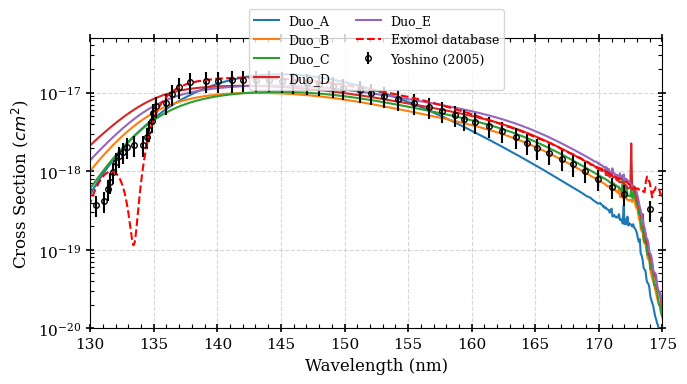

In [43]:
import duckdb
import os
import sys
import re
from math import pi
import matplotlib.pyplot as plt
import numpy as np
import warnings
from pathlib import Path
from typing import Dict, List, Tuple
from matplotlib.ticker import AutoMinorLocator
import pandas as pd
import time

# Load validation data
validation_data = pd.read_csv('/storage/home/hcoda1/9/pagrawala6/r-js130-0/0_current_best/check_full/Yoshino_2005.csv')
validation_x = validation_data.iloc[:, 0]
validation_y = validation_data.iloc[:, 1]

validation_data = pd.read_csv('/storage/home/hcoda1/9/pagrawala6/r-js130-0/0_current_best/check_full/Lu_2010.csv')
validation_x_3 = validation_data.iloc[:, 0]
validation_y_3 = validation_data.iloc[:, 1]

# ExoMol data
validation_x_2, validation_y_2 = plot_exomol_o2_cross_section(T)

# === Clean Plot ===
fig, ax = plt.subplots(figsize=(7, 4))
ax.set_xlabel('Wavelength (nm)', fontsize=12)
ax.set_ylabel(r'Cross Section ($cm^{2}$)', fontsize=12)
ax.set_xlim(130, 175)
ax.set_ylim(1e-20, 0.5e-16)
ax.set_yscale('log')

case_labels = {case: f'Duo_{case}' for case in case_ids}
for case in case_ids:
    ax.plot(1e7 / nu_range, variable_width_cs_by_case[case], label=fr'{case_labels[case]}', linestyle='-')

# Validation data with error bars
ax.errorbar(validation_x, validation_y, yerr=0.3 * validation_y, fmt='o', markersize=4, markerfacecolor='none', color='black', label='Yoshino (2005)')
ax.plot(validation_x_2, validation_y_2, color='red', label='Exomol database', linestyle='--')

# Ticks and grid
ax.tick_params(which='major', direction='inout', length=6, width=1.2, top=True, right=True, labelsize=11)
ax.tick_params(which='minor', direction='in', length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.grid(True, linestyle='--', alpha=0.5)

# Legend
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=2, fontsize=9)
plt.savefig('cont_4_300.svg', format = 'svg', bbox_inches='tight')
plt.tight_layout()
plt.show()

In [ ]:
import duckdb
import os
import sys
import re
from math import pi
import matplotlib.pyplot as plt
import numpy as np
import warnings
from pathlib import Path
from typing import Dict, List, Tuple
from matplotlib.ticker import AutoMinorLocator
import pandas as pd
import time

# Load validation data
validation_data = pd.read_csv('/storage/home/hcoda1/9/pagrawala6/r-js130-0/0_current_best/check_full/Yoshino_2005.csv')
validation_x = validation_data.iloc[:, 0]
validation_y = validation_data.iloc[:, 1]

validation_data = pd.read_csv('/storage/home/hcoda1/9/pagrawala6/r-js130-0/0_current_best/check_full/Lu_2010.csv')
validation_x_3 = validation_data.iloc[:, 0]
validation_y_3 = validation_data.iloc[:, 1]

# ExoMol data
validation_x_2, validation_y_2 = plot_exomol_o2_cross_section(T)

# === Clean Plot ===
fig, ax = plt.subplots(figsize=(7, 4))
ax.set_xlabel('Wavelength (nm)', fontsize=12)
ax.set_ylabel(r'Cross Section ($cm^{2}$)', fontsize=12)
ax.set_xlim(130, 175)
ax.set_ylim(1e-20, 0.5e-16)
ax.set_yscale('log')

case_labels = {case: f'Duo_{case}' for case in case_ids}
for case in case_ids:
    ax.plot(1e7 / nu_range, variable_width_cs_by_case[case], label=fr'{case_labels[case]}', linestyle='-')

# Validation data with error bars
ax.errorbar(validation_x, validation_y, yerr=0.3 * validation_y, fmt='o', markersize=4, markerfacecolor='none', color='black', label='Yoshino (2005)')
ax.plot(validation_x_2, validation_y_2, color='red', label='Exomol database', linestyle='--')

# Ticks and grid
ax.tick_params(which='major', direction='inout', length=6, width=1.2, top=True, right=True, labelsize=11)
ax.tick_params(which='minor', direction='in', length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.grid(True, linestyle='--', alpha=0.5)

# Legend
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=2, fontsize=9)
plt.savefig('cont_4.svg', format = 'svg', bbox_inches='tight')
plt.tight_layout()
plt.show()

## Constant $\alpha_D$ compute engine

In [33]:
# Parallel computation of the cross-section
import numpy as np
from concurrent.futures import ThreadPoolExecutor
import threading
from typing import Tuple, List
import time
c = 2.99792458e10  # speed of light in cm/s
h = 6.62607015e-34  # Planck's constant in J*s
k_B = 1.380649e-23  # Boltzmann's constant in J/K

T = 3000  # Temperature in Kelvin
Q_T = Q(T)  # Partition function at temperature T


def gaussian_lineprofile(nu, nu_nominal, alpha_D):
    """Compute Gaussian line profile"""
    return np.sqrt(np.log(2)/np.pi) * (1/alpha_D) * np.exp(-np.log(2) * (nu - nu_nominal)**2 / alpha_D**2)

def process_transition_chunk_vectorized(args):
    """
    Process a chunk of transitions using vectorized operations with frequency masking
    
    Args:
        args: tuple containing (line_positions, intensities, nu_range, alpha_D, thread_id)
    
    Returns:
        numpy array with accumulated cross-section contributions
    """
    line_positions, intensities, nu_range, alpha_D, thread_id = args
    
    # Initialize local cross-section array
    local_cross_section = np.zeros_like(nu_range)
    cutoff_range = 3 * alpha_D
    
    # Vectorized computation for this chunk
    # Create 2D arrays: (n_transitions, n_frequencies)
    nu_grid = nu_range[np.newaxis, :]  # Shape: (1, n_freq)
    pos_grid = line_positions[:, np.newaxis]  # Shape: (n_trans, 1)
    
    # Apply frequency masking: only compute within cutoff range
    mask = np.abs(nu_grid - pos_grid) <= cutoff_range
    
    # Compute Gaussian contributions only where mask is True
    distances = nu_grid - pos_grid
    gaussians = np.zeros_like(distances)
    
    # Only compute Gaussian where mask is True (keeps your masking logic)
    gaussians[mask] = (np.sqrt(np.log(2)/np.pi) * (1/alpha_D) * 
                      np.exp(-np.log(2) * distances[mask]**2 / alpha_D**2))
    
    # Weight by intensities and sum along transition axis
    weighted = gaussians * intensities[:, np.newaxis]
    local_cross_section = np.sum(weighted, axis=0)
    
    return local_cross_section

def process_transition_chunk(args):
    """
    Process a chunk of transitions with frequency masking and accumulate contributions
    
    Args:
        args: tuple containing (line_positions, intensities, nu_range, alpha_D, thread_id)
    
    Returns:
        numpy array with accumulated cross-section contributions
    """
    line_positions, intensities, nu_range, alpha_D, thread_id = args
    
    # Initialize local cross-section array
    local_cross_section = np.zeros_like(nu_range)
    
    # Process each transition in this chunk
    for central_position, intensity in zip(line_positions, intensities):
        # Apply frequency masking: only compute within 5 Doppler widths
        cutoff_range = 3 * alpha_D
        mask = (nu_range >= central_position - cutoff_range) & (nu_range <= central_position + cutoff_range)
        
            
        # Compute Gaussian contribution only for masked region
        masked_nu = nu_range[mask]
        contribution = intensity * gaussian_lineprofile(masked_nu, central_position, alpha_D)
        
        # Add contribution to local cross-section
        local_cross_section[mask] += contribution
    
    return local_cross_section

def compute_cross_section_optimized(line_positions, intensities, nu_range, alpha_D, 
                                  num_chunks=4, num_threads=None):
    """
    Compute cross-section using chunking and multithreading with frequency masking
    
    Args:
        line_positions: array of transition frequencies
        intensities: array of transition intensities
        nu_range: frequency grid for final spectrum
        alpha_D: Doppler width parameter
        num_chunks: number of chunks to divide transitions into
        num_threads: number of threads per chunk (None = auto)
    
    Returns:
        cross_section: final cross-section array
    """
    total_transitions = len(line_positions)
    # print(f"Processing {total_transitions:,} transitions in {num_chunks} chunks")
    
    # Initialize final cross-section array
    cross_section = np.zeros_like(nu_range)
    
    # Calculate chunk size
    chunk_size = total_transitions // num_chunks
    
    # Process each chunk
    for chunk_idx in range(num_chunks):
        start_idx = chunk_idx * chunk_size
        if chunk_idx == num_chunks - 1:  # Last chunk gets remaining transitions
            end_idx = total_transitions
        else:
            end_idx = (chunk_idx + 1) * chunk_size
        
        chunk_line_positions = line_positions[start_idx:end_idx]
        chunk_intensities = intensities[start_idx:end_idx]
        
        # print(f"Processing chunk {chunk_idx + 1}/{num_chunks} "
        #       f"({len(chunk_line_positions):,} transitions)")
        
        # Further divide chunk for multithreading
        if num_threads is None:
            import os
            num_threads = os.cpu_count()
        
        thread_chunk_size = len(chunk_line_positions) // num_threads
        thread_args = []
        
        for thread_idx in range(num_threads):
            thread_start = thread_idx * thread_chunk_size
            if thread_idx == num_threads - 1:  # Last thread gets remaining
                thread_end = len(chunk_line_positions)
            else:
                thread_end = (thread_idx + 1) * thread_chunk_size
            
            if thread_start < len(chunk_line_positions):
                thread_args.append((
                    chunk_line_positions[thread_start:thread_end],
                    chunk_intensities[thread_start:thread_end],
                    nu_range,
                    alpha_D,
                    thread_idx
                ))
        
        # Execute multithreaded computation for this chunk
        start_time = time.time()
        with ThreadPoolExecutor(max_workers=num_threads) as executor:
            results = list(executor.map(process_transition_chunk_vectorized, thread_args))
        
        # Accumulate results from all threads
        for result in results:
            cross_section += result
        
        chunk_time = time.time() - start_time
        # print(f"Chunk {chunk_idx + 1} completed in {chunk_time:.2f}s")
    
    return cross_section

def compute_cross_section_batch_optimized(line_positions, intensities, nu_range, alpha_D_list, 
                                        num_chunks=4, num_threads=None):
    """
    Compute cross-sections for multiple alpha_D values using optimized approach
    
    Args:
        line_positions: array of transition frequencies
        intensities: array of transition intensities
        nu_range: frequency grid for final spectrum
        alpha_D_list: list of Doppler width parameters
        num_chunks: number of chunks to divide transitions into
        num_threads: number of threads per chunk (None = auto)
    
    Returns:
        cross_section_list: list of cross-section arrays
    """
    cross_section_list = []
    
    for i, alpha_D in enumerate(alpha_D_list):
        # print(f"\nProcessing alpha_D = {alpha_D} ({i+1}/{len(alpha_D_list)})")
        start_time = time.time()
        
        cross_section = compute_cross_section_optimized(
            line_positions, intensities, nu_range, alpha_D, 
            num_chunks, num_threads
        )
        
        cross_section_list.append(cross_section)
        
        total_time = time.time() - start_time
        # print(f"Alpha_D = {alpha_D} completed in {total_time:.2f}s")
    
    return cross_section_list

# Example usage with your data
def main(alpha_D_list, nu_range, line_positions, intensities, num_chunks =4):
    # Set up frequency range
    
    
    n_transitions = len (intensities)  # 14 million transitions
    
    print(f"Starting computation with {len(line_positions):,} transitions")
    print(f"Frequency range: {nu_range.min():.1f} to {nu_range.max():.1f} cm⁻¹")
    print(f"Alpha_D values: {alpha_D_list}")
    
    # Run optimized computation
    start_time = time.time()
    cross_section_list = compute_cross_section_batch_optimized(
        line_positions, intensities, nu_range, alpha_D_list,
        num_chunks, num_threads=None  # Auto-detect thread count
    )
    
    total_time = time.time() - start_time
    print(f"\nTotal computation time: {total_time:.2f}s")
    print(f"Cross-section shapes: {[cs.shape for cs in cross_section_list]}")
    
    return cross_section_list




if __name__ == "__main__":
    # alpha_D_list = [300,1500, 3000, 5000] 
    alpha_D_list = [0.003, 3,30] 
    alpha_D_list = [30,300] 
    alpha_D_list = [15] 
    alpha_D_list = [80,160] 

    nu_range = np.linspace(1e7/180, 1e7/100, 3000)  # in cm⁻¹
    nu_range = np.linspace(1e7/550, 1e7/90, 3000)  # in cm⁻¹
    nu_range = np.linspace(1e7/750, 1e7/90, 3000)  # in cm⁻¹
    nu_range = np.linspace(1e7/600, 1e7/90, 6000)  # in cm⁻¹
    nu_range = np.linspace(1e7/200, 1e7/100, 2000)  # in cm⁻¹
    continuum['Intensity'] = 0
    continuum['Intensity'] = continuum['A'] * (2 * continuum['up_J'] + 1) * np.exp(-(h*c*(continuum['down_energy']-2.86)/(k_B * T)))  / (8.0 * np.pi*c * continuum['line_pos']**(2) * Q_T)
    

    df = continuum.sort_values(by='line_pos', ascending=True)
    
    line_positions = df['line_pos'].values
    intensities = df['Intensity'].values
    

    cross_section_list = []
    # CALLING THE MAIN CROSS-SECTION FUNCTION:
    cross_section_list = main(alpha_D_list, nu_range, line_positions, intensities, 100)
    
    
    # doing 4 chunks at this time, can decrease if each "list" is smaller or larger, remember that each "chunk" is then parallelized, so chunks are really number of passes

Starting computation with 8,679,633 transitions
Frequency range: 50000.0 to 100000.0 cm⁻¹
Alpha_D values: [80, 160]

Total computation time: 35.17s
Cross-section shapes: [(2000,), (2000,)]


Fetching data for T = 3000 K from https://www.exomol.com/db/O2/16O2/PhoMol/16O2__PhoMol__50.0-500.0__3000__0__0.1.photo


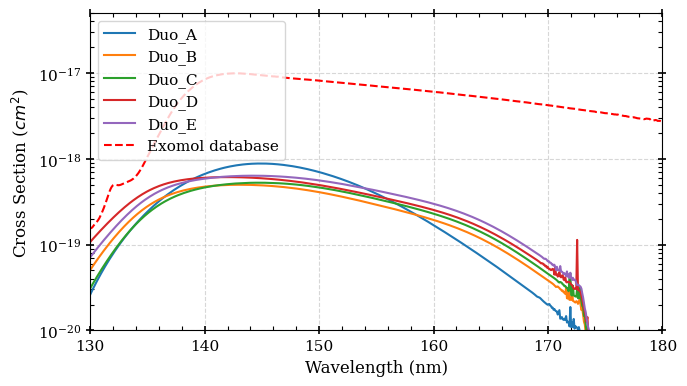

Integral of variable width cross-section: -1.584e-17 cm^2 nm
Integral of ExoMol cross-section (120–185 nm): 2.891e-16 cm^2 nm
Integral of ExoMol cross-section: 2.891e-16 cm^2 nm
Integral of cross-section for alpha_D = 80: -2.955e-16 cm^2 nm
Integral of cross-section for alpha_D = 160: -2.955e-16 cm^2 nm


In [34]:
import duckdb
import os
import sys
import re
from math import pi
import matplotlib.pyplot as plt
import numpy as np
import warnings
from pathlib import Path
from typing import Dict, List, Tuple
from matplotlib.ticker import AutoMinorLocator
import pandas as pd
import time

# # Load validation data
# validation_data = pd.read_csv('/storage/home/hcoda1/9/pagrawala6/r-js130-0/0_current_best/check_full/Yoshino_2005.csv')
# validation_x = validation_data.iloc[:, 0]
# validation_y = validation_data.iloc[:, 1]

# validation_data = pd.read_csv('/storage/home/hcoda1/9/pagrawala6/r-js130-0/0_current_best/check_full/Lu_2010.csv')
# validation_x_3 = validation_data.iloc[:, 0]
# validation_y_3 = validation_data.iloc[:, 1]

# ExoMol data
validation_x_2, validation_y_2 = plot_exomol_o2_cross_section(T)

# === Clean Plot ===
fig, ax = plt.subplots(figsize=(7, 4))
ax.set_xlabel('Wavelength (nm)', fontsize=12)
ax.set_ylabel(r'Cross Section ($cm^{2}$)', fontsize=12)
ax.set_xlim(130, 180)
ax.set_ylim(1e-20, 0.5e-16)
ax.set_yscale('log')

case_labels = {case: f'Duo_{case}' for case in case_ids}
for case in case_ids:
    ax.plot(1e7 / nu_range, variable_width_cs_by_case[case], label=case_labels[case], linestyle='-')

# Validation data with error bars
# ax.errorbar(validation_x, validation_y, yerr=0.3 * validation_y, fmt='o', markersize=4, markerfacecolor='none', color='black', label='Yoshino (2005)')
ax.plot(validation_x_2, validation_y_2, color='red', label='Exomol database', linestyle='--')

# Ticks and grid
ax.tick_params(which='major', direction='inout', length=6, width=1.2, top=True, right=True, labelsize=11)
ax.tick_params(which='minor', direction='in', length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.grid(True, linestyle='--', alpha=0.5)

# Legend
ax.legend(loc='best')
# plt.title('O$_2$  Cross Sections T = 300K', fontsize=14)
plt.tight_layout()
plt.savefig('cont_4.pdf', format = 'pdf', bbox_inches='tight')

plt.show()

# print numerical integral over the range of interest for the variable width case, and compare to the ExoMol data integral and the fixed width cases np.trapz
if 'variable_width_cs' in locals():
    variable_integral = np.trapz(variable_width_cs, 1e7 / nu_range)
    print(f"Integral of variable width cross-section: {variable_integral:.3e} cm^2 nm")

#. we wish to truncate exo_integral to the same wavelength range as our nu_range, which is 100-200 nm, so we need to find the indices of validation_x_2 that correspond to this range


# Truncate ExoMol data to the same wavelength window as your model (100–200 nm)
wl_min, wl_max = 125.0, 185.0
mask = (validation_x_2 >= wl_min) & (validation_x_2 <= wl_max)

x_exo_cut = validation_x_2[mask]
y_exo_cut = validation_y_2[mask]

if x_exo_cut.size < 2:
    raise ValueError("Not enough ExoMol points inside 120–185 nm to integrate.")

# Optional: ensure ascending wavelength before integration
order = np.argsort(x_exo_cut)
x_exo_cut = x_exo_cut[order]
y_exo_cut = y_exo_cut[order]

exo_integral = np.trapz(y_exo_cut, x_exo_cut)
print(f"Integral of ExoMol cross-section (120–185 nm): {exo_integral:.3e} cm^2 nm")


print(f"Integral of ExoMol cross-section: {exo_integral:.3e} cm^2 nm")
for alpha_D, cs in zip(alpha_D_list, cross_section_list):
    integral = np.trapz(cs, 1e7 / nu_range)
    print(f"Integral of cross-section for alpha_D = {alpha_D}: {integral:.3e} cm^2 nm")


SyntaxError: incomplete input (495427234.py, line 2)

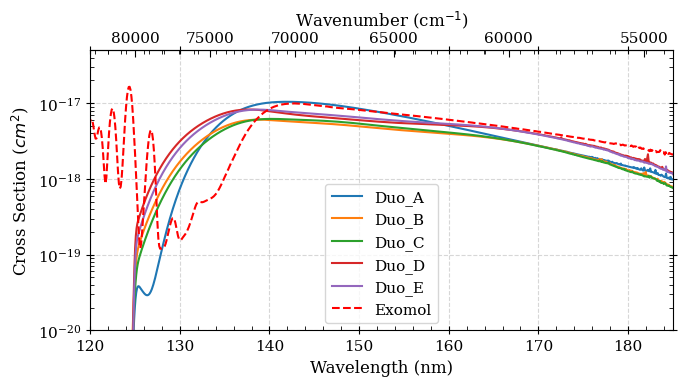

In [58]:
from matplotlib.ticker import AutoMinorLocator
import numpy as np
import matplotlib.pyplot as plt

# ──────────────────────────────────────────────
# Conversion functions
# ──────────────────────────────────────────────
def wl_to_wn(wl_nm):
    wl_nm = np.asarray(wl_nm)
    return 1e7 / wl_nm

def wn_to_wl(wn):
    wn = np.asarray(wn)
    out = np.full_like(wn, np.inf, dtype=float)
    return np.divide(1e7, wn, out=out, where=wn != 0)

# ──────────────────────────────────────────────
# Plot
# ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

ax.set_xlabel('Wavelength (nm)', fontsize=12)
ax.set_ylabel(r'Cross Section ($cm^{2}$)', fontsize=12)

ax.set_xlim(120, 185)
ax.set_ylim(1e-20, 0.5e-16)
ax.set_yscale('log')

# --- Model spectra ---
case_labels = {case: f'Duo_{case}' for case in case_ids}
for case in case_ids:
    ax.plot(
        1e7 / nu_range, variable_width_cs_by_case[case],
        linestyle='-',
        label=case_labels[case]
    )

# --- ExoMol ---
ax.plot(
    validation_x_2, validation_y_2,
    linestyle='--', color='red',
    label='Exomol'
)

# ──────────────────────────────────────────────
# Secondary X-axis (wavenumber)
# ──────────────────────────────────────────────
secax = ax.secondary_xaxis('top', functions=(wl_to_wn, wn_to_wl))
secax.set_xlabel(r'Wavenumber (cm$^{-1}$)', fontsize=12)

# ──────────────────────────────────────────────
# Styling
# ──────────────────────────────────────────────
ax.tick_params(which='major', direction='inout', length=6, top=True, right=True, labelsize=11)
ax.tick_params(which='minor', direction='in', length=3, top=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator())

secax.tick_params(which='major', direction='in', length=5)
secax.tick_params(which='minor', direction='in', length=3)
secax.xaxis.set_minor_locator(AutoMinorLocator())

ax.grid(True, linestyle='--', alpha=0.5)

ax.legend(loc='best')
plt.savefig('cont_6.svg', format = 'svg', bbox_inches='tight')
plt.tight_layout()
plt.show()